In [8]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
import random

In [9]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [10]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-2.037347,-2.256929,-1.356696,0.033514,-1.256937,1
1,0.395453,-1.367646,0.416370,1.893374,-0.458783,0
2,0.824344,-0.153786,0.791208,0.692262,-1.360207,0
3,-1.945796,-0.638706,-0.735236,0.518008,1.816676,1
4,1.383205,0.075662,1.211818,-1.190517,-2.058530,0


In [11]:
# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [12]:
# function for feature sampling
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [13]:
# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [14]:
df1 = combined_sampling(df,0.5,0.5)

C:\Users\Rafy Mustafa\AppData\Local\Temp\ipykernel_11468\3275485051.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [15]:
df2 = combined_sampling(df,0.5,0.5)

C:\Users\Rafy Mustafa\AppData\Local\Temp\ipykernel_11468\3275485051.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [16]:
df3 = combined_sampling(df,0.5,0.5)

C:\Users\Rafy Mustafa\AppData\Local\Temp\ipykernel_11468\3275485051.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [17]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col5', 'col4', 'target'], dtype='object')
Index(['col4', 'col5', 'target'], dtype='object')
Index(['col4', 'col2', 'target'], dtype='object')


In [18]:
df3

,col4,col2,target
33,1.027891,-0.897362,1
30,0.941316,-2.259131,1
71,1.364470,-1.838690,0
71,1.364470,-1.838690,0
26,-0.238756,0.160154,0
35,0.781937,0.136515,0
16,-0.055636,0.518297,0
89,-0.663473,0.314607,1
24,0.495658,-0.413245,0
19,1.896214,-3.334566,1


In [19]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [20]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

DecisionTreeClassifier()

In [21]:
from sklearn.tree import plot_tree

[Text(0.6, 0.9285714285714286, 'x[0] <= -0.369\ngini = 0.499\nsamples = 50\nvalue = [26, 24]'),
 Text(0.4, 0.7857142857142857, 'x[1] <= 1.916\ngini = 0.191\nsamples = 28\nvalue = [25, 3]'),
 Text(0.5, 0.8571428571428572, 'True  '),
 Text(0.3, 0.6428571428571429, 'x[0] <= -1.732\ngini = 0.291\nsamples = 17\nvalue = [14, 3]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 10\nvalue = [10, 0]'),
 Text(0.4, 0.5, 'x[0] <= -0.755\ngini = 0.49\nsamples = 7\nvalue = [4, 3]'),
 Text(0.3, 0.35714285714285715, 'x[1] <= 0.684\ngini = 0.375\nsamples = 4\nvalue = [1, 3]'),
 Text(0.2, 0.21428571428571427, 'x[0] <= -1.3\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.1, 0.07142857142857142, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.3, 0.07142857142857142, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.4, 0.21428571428571427, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.5, 0.35714285714285715, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.5, 0.6428571428571429, 'gini = 0.0\nsam

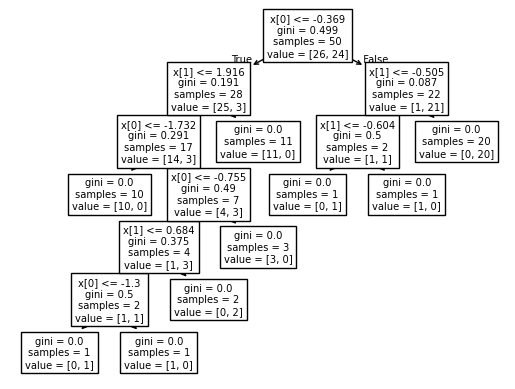

In [22]:
plot_tree(clf1)

[Text(0.6363636363636364, 0.9444444444444444, 'x[1] <= 0.121\ngini = 0.493\nsamples = 50\nvalue = [22.0, 28.0]'),
 Text(0.45454545454545453, 0.8333333333333334, 'x[0] <= 0.984\ngini = 0.384\nsamples = 27\nvalue = [20, 7]'),
 Text(0.5454545454545454, 0.8888888888888888, 'True  '),
 Text(0.36363636363636365, 0.7222222222222222, 'x[1] <= -1.702\ngini = 0.475\nsamples = 18\nvalue = [11, 7]'),
 Text(0.2727272727272727, 0.6111111111111112, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.45454545454545453, 0.6111111111111112, 'x[1] <= -0.267\ngini = 0.497\nsamples = 13\nvalue = [6, 7]'),
 Text(0.36363636363636365, 0.5, 'x[1] <= -1.259\ngini = 0.42\nsamples = 10\nvalue = [3, 7]'),
 Text(0.2727272727272727, 0.3888888888888889, 'x[1] <= -1.3\ngini = 0.48\nsamples = 5\nvalue = [3, 2]'),
 Text(0.18181818181818182, 0.2777777777777778, 'x[0] <= -0.66\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.09090909090909091, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.2

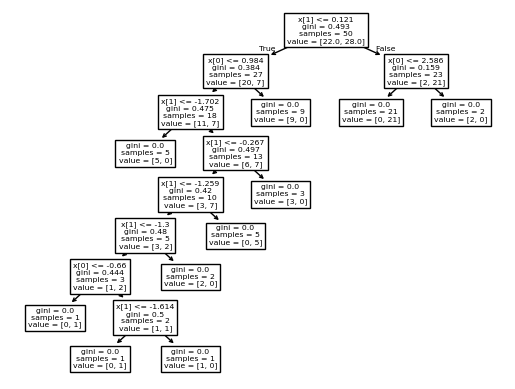

In [23]:
plot_tree(clf2)

[Text(0.4166666666666667, 0.9444444444444444, 'x[0] <= 0.52\ngini = 0.499\nsamples = 50\nvalue = [26, 24]'),
 Text(0.16666666666666666, 0.8333333333333334, 'x[1] <= -2.005\ngini = 0.375\nsamples = 20\nvalue = [15, 5]'),
 Text(0.2916666666666667, 0.8888888888888888, 'True  '),
 Text(0.08333333333333333, 0.7222222222222222, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.25, 0.7222222222222222, 'x[0] <= -0.638\ngini = 0.278\nsamples = 18\nvalue = [15, 3]'),
 Text(0.16666666666666666, 0.6111111111111112, 'x[0] <= -1.102\ngini = 0.5\nsamples = 6\nvalue = [3, 3]'),
 Text(0.08333333333333333, 0.5, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.25, 0.5, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.3333333333333333, 0.6111111111111112, 'gini = 0.0\nsamples = 12\nvalue = [12, 0]'),
 Text(0.6666666666666666, 0.8333333333333334, 'x[0] <= 3.082\ngini = 0.464\nsamples = 30\nvalue = [11, 19]'),
 Text(0.5416666666666666, 0.8888888888888888, '  False'),
 Text(0.5833333333333334, 0.7222

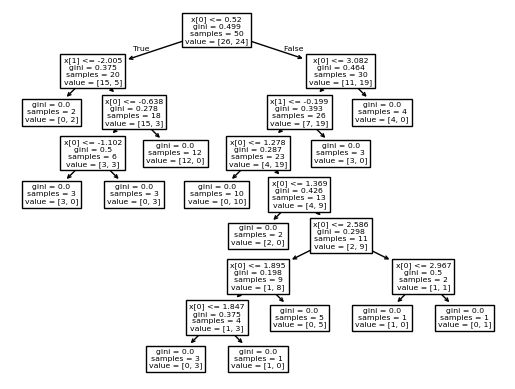

In [24]:
plot_tree(clf3)

In [25]:
clf1.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

C:\Users\Rafy Mustafa\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [26]:
clf2.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

C:\Users\Rafy Mustafa\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [27]:
clf3.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

C:\Users\Rafy Mustafa\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [28]:
df.sample(14,replace=True)

,col1,col2,col3,col4,col5,target
71,0.933493,-1.838690,0.069799,1.364470,0.141870,0
49,-1.266962,-1.839352,0.190797,2.210033,1.596889,1
82,-1.698013,-2.310765,-1.339590,0.943768,-1.651694,1
62,0.762267,0.220320,-0.203224,-0.166745,0.052392,0
97,1.042872,-2.959902,0.460250,3.844585,-0.655090,0
94,0.062704,-1.349470,0.603696,2.479324,-1.295464,0
75,1.260497,-0.353429,2.049647,-0.613078,-2.211074,0
64,-0.842422,-0.852604,-0.820843,0.985748,1.039548,1
76,2.418744,-1.746431,-0.613086,4.008183,-0.623514,0
36,2.822057,-3.267153,0.672521,4.018016,-0.782890,0
